# **Purpose**

The purpose of this notebook is to evaluate the fine-tuned BART-base-DG
(distractor generation) model. It scores the model on a **fixed RACE test
split**, so results are directly comparable across all the models
(T5-base, BART-base, Flan-T5-base).

**Metrics:** BLEU, ROUGE-1/2/L, METEOR, GPT-2 perplexity (fluency),
Distinct-1/2 (diversity), and distractor-vs-answer semantic similarity
(plausibility).

**How to reuse across models:** change `MODEL_REPO` in the config cell, then
rerun the whole notebook. Keep `TEST_SIZE` and `SEED` identical across every
run so all models are scored on the exact same (context, question, answer) →
distractor pairs.

## **Install dependencies**

In [1]:
!pip install -qU \
 transformers \
 evaluate \
 rouge_score \
 sacrebleu \
 nltk \
 sentence-transformers \
 matplotlib \
 torch \
 torchvision \
 torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197

In [2]:
import os
os.environ["NLTK_ALLOW_PROXIED_URLOPEN"] = "1"

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

## **Imports**

In [3]:
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    GPT2Tokenizer,
)
from sentence_transformers import SentenceTransformer, util as st_util
import evaluate

from kaggle_secrets import UserSecretsClient

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## **Load the API Keys and Tokens**

In [4]:
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")   # must match the exact secret name you set in Kaggle Secrets

os.environ["HF_TOKEN"] = hf_token

## **Config**

- `MODEL_REPO`: the Hugging Face Hub repo of the fine-tuned model we want to evaluate.
- `MODEL_TYPE`: `"seq2seq"` for T5/BART/Flan-T5 (all three DG models use this).
- `TEST_SIZE` / `SEED`: **We need to keep these identical across every model
  we evaluate** — this is what makes the comparison fair.

In [5]:
MODEL_REPO = "gaurav-dey/bart-base-dg"   # change this per model
MODEL_TYPE = "seq2seq"                  # "seq2seq" for T5/BART/Flan-T5

TEST_SIZE = 1500      # keep identical across all models you compare
SEED = 42              # keep identical across all models you compare

NUM_BEAMS = 4
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 48

OUTPUT_JSON = f"/kaggle/working/eval_results_{MODEL_REPO.split('/')[-1]}.json"

## **Load the fixed test split**

RACE gives 3 gold distractors per question, so we first expand the full test
set into individual (context, question, correct answer) → gold-distractor
pairs, then shuffle those pairs with a fixed seed and take the first
`TEST_SIZE`. As long as `TEST_SIZE`/`SEED` don't change between runs, every
model we evaluate is scored on the exact same pairs.

In [6]:
LETTER_TO_IDX = {"A": 0, "B": 1, "C": 2, "D": 3}

raw = load_dataset("race", "all")
test_examples = raw["test"]

flat_contexts, flat_questions, flat_answers, flat_distractors = [], [], [], []
for ex in test_examples:
    answer_letter = ex["answer"]
    if answer_letter not in LETTER_TO_IDX:
        continue
    correct_idx = LETTER_TO_IDX[answer_letter]
    options = ex["options"]
    if correct_idx >= len(options):
        continue
    correct_answer = options[correct_idx]

    for i, option in enumerate(options):
        if i == correct_idx or not option.strip():
            continue
        flat_contexts.append(ex["article"])
        flat_questions.append(ex["question"])
        flat_answers.append(correct_answer)
        flat_distractors.append(option)

print(f"Total (context, question, answer) -> gold distractor pairs available: {len(flat_distractors)}")

indices = list(range(len(flat_distractors)))
random.Random(SEED).shuffle(indices)
indices = indices[:TEST_SIZE]

contexts = [flat_contexts[i] for i in indices]
questions = [flat_questions[i] for i in indices]
correct_answers = [flat_answers[i] for i in indices]
gold_distractors = [flat_distractors[i] for i in indices]

print(f"Evaluating on {len(gold_distractors)} pairs")

README.md: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

all/train-00000-of-00001.parquet:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4934 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/87866 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4887 [00:00<?, ? examples/s]

Total (context, question, answer) -> gold distractor pairs available: 14802
Evaluating on 1500 pairs


## **Load the model and tokenizer from the Hub**

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)

if MODEL_TYPE == "seq2seq":
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_REPO).to(device)
else:
    model = AutoModelForCausalLM.from_pretrained(MODEL_REPO).to(device)

model.eval()
print(f"Loaded {MODEL_REPO} ({MODEL_TYPE})")

# Used later for the distractor-vs-answer semantic plausibility metric
embedder = SentenceTransformer("all-MiniLM-L6-v2")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/416 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **Prompt builder**

Must match whatever format the model was fine-tuned with (correct answer and
question placed BEFORE the context, so truncation only ever eats into the
context).

In [8]:
def build_prompt(context, question, correct_answer):
    return (
        f"Correct Answer: {correct_answer}\n"
        f"Question: {question}\n"
        f"Generate a plausible but incorrect answer option (a distractor) for the question "
        f"above, based on the context below. The distractor must be clearly wrong but related "
        f"to the topic, so that a student with a misconception could mistake it for the "
        f"correct answer.\n"
        f"Context: {context}"
    )

## **Generate predictions on the fixed test split**

In [9]:
predictions, references = [], []

with torch.no_grad():
    for context, question, correct_answer, gold in zip(
        contexts, questions, correct_answers, gold_distractors
    ):
        prompt = build_prompt(context, question, correct_answer)

        inputs = tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LENGTH
        ).to(device)

        if MODEL_TYPE == "seq2seq":
            output_ids = model.generate(
                **inputs, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS
            )
            generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        else:  # causal LM: only decode the newly generated continuation
            output_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_TARGET_LENGTH,
                num_beams=NUM_BEAMS,
                pad_token_id=tokenizer.eos_token_id,
            )
            new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
            generated = tokenizer.decode(new_tokens, skip_special_tokens=True)

        predictions.append(generated.strip())
        references.append(gold.strip())

print(f"Generated {len(predictions)} predictions.")

Generated 1500 predictions.


## **Reference-based metrics: BLEU, ROUGE-1/2/L, METEOR**

In [10]:
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

bleu_score = bleu.compute(
    predictions=predictions, references=[[r] for r in references]
)["score"]

rouge_scores = rouge.compute(predictions=predictions, references=references)

meteor_score = meteor.compute(predictions=predictions, references=references)["meteor"]

print(f"BLEU:    {bleu_score:.4f}")
print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")
print(f"METEOR:  {meteor_score:.4f}")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


BLEU:    5.0355
ROUGE-1: 0.1963
ROUGE-2: 0.0545
ROUGE-L: 0.1904
METEOR:  0.1732


## **Diversity metrics: Distinct-1 / Distinct-2**

Corpus-level, reference-free — flags repetitive/templated distractor
generation (e.g. always producing a near-copy of the correct answer, or the
same generic wrong answer regardless of question).

In [11]:
def distinct_n(preds, n):
    all_ngrams = []
    for pred in preds:
        tokens = pred.split()
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


distinct_1 = distinct_n(predictions, 1)
distinct_2 = distinct_n(predictions, 2)

print(f"Distinct-1: {distinct_1:.4f}")
print(f"Distinct-2: {distinct_2:.4f}")

Distinct-1: 0.3007
Distinct-2: 0.6897


## **Fluency metric: GPT-2 perplexity**

Reference-free — measures how natural the generated distractors read on
their own, independent of closeness to the gold distractor.

In [12]:
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_model.eval()

perplexities = []
with torch.no_grad():
    for text in predictions:
        if not text.strip():
            continue
        encodings = gpt2_tokenizer(text, return_tensors="pt").to(device)
        input_ids = encodings["input_ids"]
        if input_ids.shape[1] < 2:
            continue  # too short to compute a meaningful loss
        outputs = gpt2_model(input_ids, labels=input_ids)
        perplexities.append(torch.exp(outputs.loss).item())

perplexity = float(np.mean(perplexities)) if perplexities else float("nan")
print(f"GPT-2 perplexity: {perplexity:.4f}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


GPT-2 perplexity: 1821.6308


## **Semantic plausibility: distractor-vs-answer cosine similarity**

A good distractor should be *related* to the correct answer (high-ish
similarity) without being so close that it could also be considered correct.
We embed each generated distractor and its corresponding correct answer with
a sentence encoder and look at the cosine similarity distribution — this
visualizes the "plausibility-validity paradox" from the literature review:
too low similarity means an implausible/off-topic distractor, too high means
the distractor risks being a second valid answer.

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Mean distractor-answer similarity: 0.5399
Std dev: 0.2700
% of distractors with similarity > 0.9 (risk of being a valid alternative answer): 12.6%


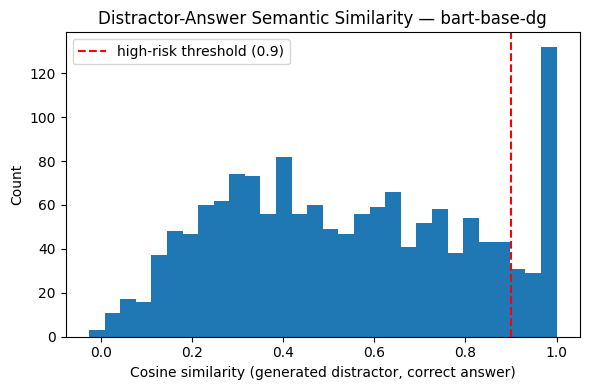

In [13]:
pred_emb = embedder.encode(predictions, convert_to_tensor=True, show_progress_bar=True)
answer_emb = embedder.encode(correct_answers, convert_to_tensor=True, show_progress_bar=True)

similarities = st_util.cos_sim(pred_emb, answer_emb).diagonal().cpu().numpy()

mean_similarity = float(similarities.mean())
pct_high_risk = float((similarities > 0.9).mean() * 100)

print(f"Mean distractor-answer similarity: {mean_similarity:.4f}")
print(f"Std dev: {similarities.std():.4f}")
print(f"% of distractors with similarity > 0.9 (risk of being a valid alternative answer): "
      f"{pct_high_risk:.1f}%")

plt.figure(figsize=(6, 4))
plt.hist(similarities, bins=30)
plt.axvline(0.9, color="red", linestyle="--", label="high-risk threshold (0.9)")
plt.xlabel("Cosine similarity (generated distractor, correct answer)")
plt.ylabel("Count")
plt.title(f"Distractor-Answer Semantic Similarity — {MODEL_REPO.split('/')[-1]}")
plt.legend()
plt.tight_layout()
plt.savefig(f"/kaggle/working/similarity_distribution_{MODEL_REPO.split('/')[-1]}.png", dpi=150)
plt.show()

## **Assemble and save results**

In [14]:
results = {
    "model_repo": MODEL_REPO,
    "model_type": MODEL_TYPE,
    "test_size": TEST_SIZE,
    "seed": SEED,
    "bleu": bleu_score,
    "rouge1": rouge_scores["rouge1"],
    "rouge2": rouge_scores["rouge2"],
    "rougeL": rouge_scores["rougeL"],
    "meteor": meteor_score,
    "gpt2_perplexity": perplexity,
    "distinct_1": distinct_1,
    "distinct_2": distinct_2,
    "mean_answer_similarity": mean_similarity,
    "pct_high_risk_similarity": pct_high_risk,
}

print("=== Results ===")
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(
        {
            "results": results,
            "sample_predictions": [
                {"correct_answer": a, "gold_distractor": r, "generated_distractor": p}
                for a, r, p in list(zip(correct_answers, references, predictions))[:10]
            ],
        },
        f,
        indent=2,
    )

print(f"\nSaved results + sample predictions to {OUTPUT_JSON}")

=== Results ===
model_repo          : gaurav-dey/bart-base-dg
model_type          : seq2seq
test_size           : 1500
seed                : 42
bleu                : 5.0355
rouge1              : 0.1963
rouge2              : 0.0545
rougeL              : 0.1904
meteor              : 0.1732
gpt2_perplexity     : 1821.6308
distinct_1          : 0.3007
distinct_2          : 0.6897
mean_answer_similarity: 0.5399
pct_high_risk_similarity: 12.6000

Saved results + sample predictions to /kaggle/working/eval_results_bart-base-dg.json


## **Inspect sample generations**

In [15]:
for a, r, p in list(zip(correct_answers, references, predictions))[:10]:
    print(f"Correct answer:       {a}")
    print(f"Gold distractor:      {r}")
    print(f"Generated distractor: {p}")
    print("-" * 80)

Correct answer:       Working or talking with students.
Gold distractor:      Having a basketball game.
Generated distractor: Watching the football game.
--------------------------------------------------------------------------------
Correct answer:       we must know who we are
Gold distractor:      we should know what we do
Generated distractor: we must know who we are
--------------------------------------------------------------------------------
Correct answer:       the high quality education and research and the wide range of courses
Gold distractor:      the convenient traffic
Generated distractor: the large number of students and universities
--------------------------------------------------------------------------------
Correct answer:       they watch TV late
Gold distractor:      they play the computer games late into the night
Generated distractor: they are too tired
--------------------------------------------------------------------------------
Correct answer:       it

## **Next steps**

- Collect each run's `eval_results_*.json` into a single comparison table for
  the M.Tech project report (T5-base vs. BART-base vs. Flan-T5-base).
- Compare the `mean_answer_similarity` / `pct_high_risk_similarity` and
  `similarity_distribution_*.png` plots across the three models to see which
  backbone strikes the best plausibility-validity balance.
- Once this evaluation is paired with the question-generation output, add an
  Item-Writing-Flaw pass rate / SAQUET-style check on the assembled full MCQ
  items.